# Customer Churn Prediction using Explainable AI

## Notebook 06: Model Evaluation

## Project Overview

In the previous phase, four machine learning classification models were trained to predict customer churn:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

The trained models generated predictions and churn probabilities on the test dataset.

This notebook focuses on evaluating and comparing the performance of these trained models using appropriate classification metrics and visualizations.

The evaluation will help determine which model provides the most suitable performance for the customer churn prediction problem.

The selected model will be carried forward to the Explainable AI phase, where SHAP will be used to understand the factors influencing its predictions.

## Objectives

The objectives of this notebook are to:

- Load the test data and predictions generated during model training.
- Evaluate all trained classification models.
- Calculate accuracy, precision, recall, F1-score, and ROC-AUC.
- Analyze model performance using confusion matrices.
- Examine class-wise performance using classification reports.
- Compare ROC curves of all models.
- Compare the overall performance of the trained models.
- Select the most suitable model for the next phase.
- Save the model evaluation results.
- Save the selected final model for Explainable AI and deployment.

## Importing Required Libraries:

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",None)

## Load Trained Models

The trained models saved in Notebook 05 are loaded for evaluation.

The saved file contains the complete machine learning pipelines, including preprocessing and the trained models.

In [ ]:
models = joblib.load("/content/churn_models.pkl")
print(models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'])


## Load Evaluation Data

The test dataset and model predictions generated in the previous notebook are loaded from the saved evaluation file.

The evaluation file contains:

- X_test: Test feature data
- y_test: Actual churn outcomes
- Predictions: Predicted churn classes from each model
- Probabilities: Predicted churn probabilities from each model

These values allow the models to be evaluated without retraining them or generating predictions again.

In [ ]:
evaluation_data = joblib.load("/content/Evaluation_data.pkl")
print(evaluation_data.keys())

dict_keys(['y_test', 'x_test', 'Predictions', 'Probabilities'])


## Extracting Evaluation Data:

In [ ]:
x_test = evaluation_data["x_test"]
y_test = evaluation_data["y_test"]
predictions = evaluation_data["Predictions"]
probabilities = evaluation_data["Probabilities"]

print(x_test.shape)
print(y_test.shape)

(1409, 25)
(1409,)


## Evaluation Setup

The actual outcomes in `y_test` represent the true churn status of the customers in the test dataset.

The `predictions` dictionary contains the predicted churn class from each model, while the `probabilities` dictionary contains the predicted probability of churn.

These values are compared to evaluate the performance of each model.

## Accuracy

Accuracy measures the proportion of total predictions that were classified correctly.

It provides an overall view of model performance but should not be considered alone because the primary objective of this project is to identify customers who are likely to churn.

In [ ]:
accuracy_results= []
for model_name in predictions:
    accuracy = accuracy_score(y_test, predictions[model_name])
    accuracy_results.append([model_name,accuracy])
print(accuracy_results)

[['Logistic Regression', 0.8005677785663591], ['Decision Tree', 0.7934705464868701], ['Random Forest', 0.7856635911994322], ['XGBoost', 0.8034066713981547]]


## Precision

Precision measures the proportion of customers predicted as churners who actually churned.

Higher precision means that fewer customers are incorrectly identified as potential churners.

In [ ]:
precision_results = []
for model_name in predictions:
    Precision = precision_score(y_test,predictions[model_name])
    precision_results.append([model_name,Precision])
print(precision_results)

[['Logistic Regression', 0.6466876971608833], ['Decision Tree', 0.6143250688705234], ['Random Forest', 0.6241379310344828], ['XGBoost', 0.6579804560260586]]


## Recall

Recall measures the proportion of actual churners that were correctly identified by the model.

A high recall means that the model is able to identify a larger proportion of customers who are actually going to churn.

Recall is particularly important in customer churn prediction because failing to identify a potential churner may result in a missed retention opportunity.

In [ ]:
recall_results = []
for model_name in predictions:
    recall = recall_score(y_test,predictions[model_name])
    recall_results.append([model_name,recall])
print(recall_results)

[['Logistic Regression', 0.5481283422459893], ['Decision Tree', 0.5962566844919787], ['Random Forest', 0.4839572192513369], ['XGBoost', 0.5401069518716578]]


## F1-Score

The F1-score combines precision and recall into a single metric.

It is the harmonic mean of precision and recall and provides a balanced measure of classification performance.

A higher F1-score indicates a better balance between identifying churners and avoiding incorrect churn predictions.

In [ ]:
f1_score_results= []
for model_name in predictions:
    F1_score = f1_score(y_test,predictions[model_name])
    f1_score_results.append([model_name,F1_score])
print(f1_score_results)

[['Logistic Regression', 0.5933429811866859], ['Decision Tree', 0.6051560379918589], ['Random Forest', 0.5451807228915663], ['XGBoost', 0.593245227606461]]


## ROC-AUC Score

ROC-AUC measures how effectively a model distinguishes between customers who churn and customers who do not churn across different classification thresholds.

A higher ROC-AUC score indicates better ability to separate the two classes.

In [ ]:
roc_auc_results = []
for model_name in probabilities:
    roc_auc = roc_auc_score(y_test,probabilities[model_name])
    roc_auc_results.append([model_name,roc_auc])
print(roc_auc_results)

[['Logistic Regression', np.float64(0.8493631971892842)], ['Decision Tree', np.float64(0.8345061871916093)], ['Random Forest', np.float64(0.8367834353767857)], ['XGBoost', np.float64(0.851788989640652)]]


## Combining into a table:

In [ ]:
results_df  = pd.DataFrame(
    {
        "Model":[x[0] for x in accuracy_results],                          # set name "x" for each inner list inside outer list one by one
        "Accuracy":[x[1] for x in accuracy_results],
        "Precision":[x[1] for x in precision_results],
        "Recall":[x[1] for x in recall_results],
        "F1-Score":[x[1] for x in f1_score_results],
        "ROC-AUC":[x[1] for x in roc_auc_results]
    }
)
print(results_df.head())
print(results_df.shape)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.800568   0.646688  0.548128  0.593343  0.849363
1        Decision Tree  0.793471   0.614325  0.596257  0.605156  0.834506
2        Random Forest  0.785664   0.624138  0.483957  0.545181  0.836783
3              XGBoost  0.803407   0.657980  0.540107  0.593245  0.851789
(4, 6)


## Model Ranking

The models are ranked primarily using F1-score because it provides a balance between precision and recall.

Recall and ROC-AUC are also given particular consideration because the objective is to identify customers who are at risk of churn.

The final model selection will therefore consider the overall performance across multiple metrics rather than relying on a single metric.

In [ ]:
ranked_models = results_df.sort_values(
    by="F1-Score",
    ascending=False
)
print(ranked_models.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1        Decision Tree    0.7935     0.6143  0.5963    0.6052   0.8345
0  Logistic Regression    0.8006     0.6467  0.5481    0.5933   0.8494
3              XGBoost    0.8034     0.6580  0.5401    0.5932   0.8518
2        Random Forest    0.7857     0.6241  0.4840    0.5452   0.8368


## Model Performance Visualization:

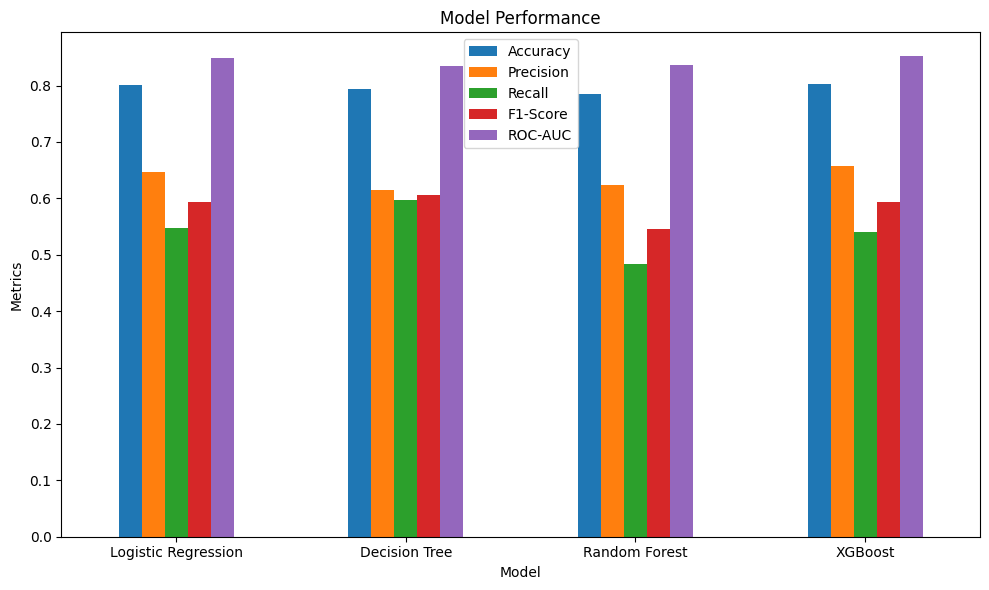

In [ ]:
results_df.plot(
    kind = "bar",
    figsize = (10,6),
    x = "Model",
    y = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
)
plt.title("Model Performance")
plt.xlabel("Model")
plt.ylabel("Metrics")
plt.xticks(rotation = 0)
plt.legend(loc = "upper center")
plt.tight_layout()
plt.show()

## Confusion Matrix

A confusion matrix provides a detailed view of correct and incorrect predictions.

It contains four outcomes:

- True Negative: A non-churn customer correctly predicted as non-churn.
- False Positive: A non-churn customer incorrectly predicted as churn.
- False Negative: A churned customer incorrectly predicted as non-churn.
- True Positive: A churned customer correctly predicted as churn.

False negatives are particularly important in this project because they represent customers who actually churned but were not identified by the model.

In [ ]:
confusion_metrics_results = []
for model_name in predictions:
    cm = confusion_matrix(y_test,predictions[model_name])
    confusion_metrics_results.append([model_name,cm])
print(confusion_metrics_results)

[['Logistic Regression', array([[923, 112],
       [169, 205]])], ['Decision Tree', array([[895, 140],
       [151, 223]])], ['Random Forest', array([[926, 109],
       [193, 181]])], ['XGBoost', array([[930, 105],
       [172, 202]])]]


## Visualization:

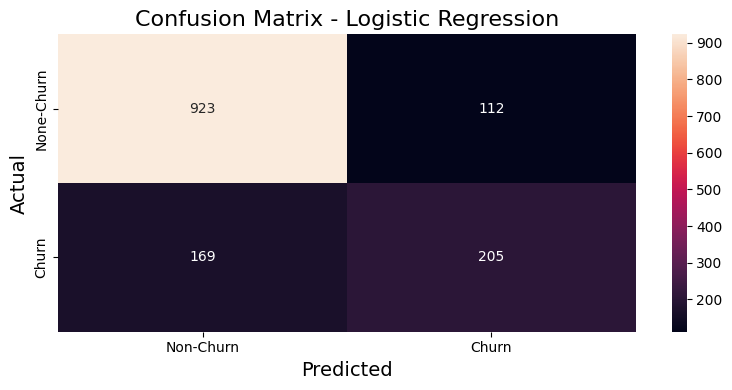

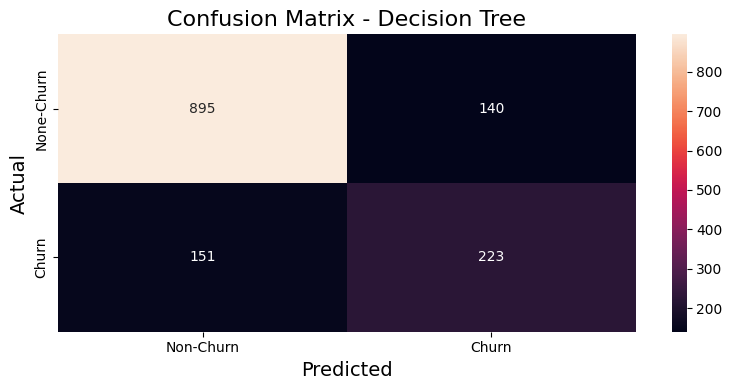

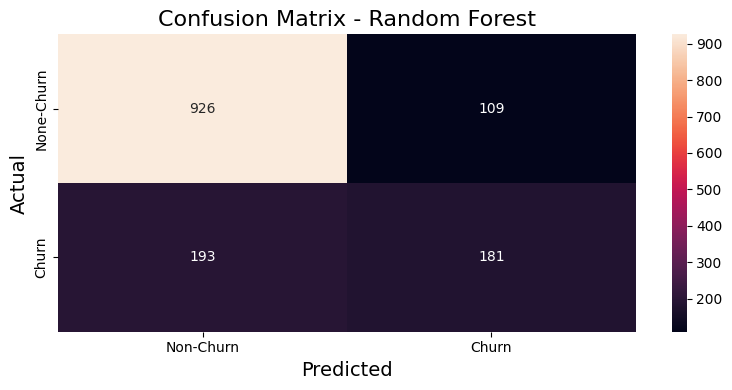

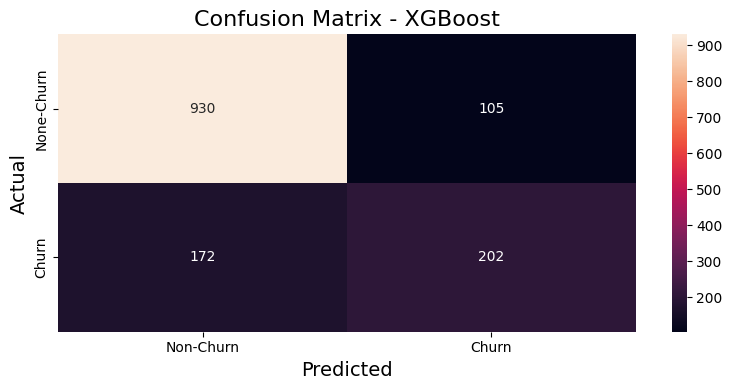

In [ ]:
for results in confusion_metrics_results:
    model = results[0]
    cm = results[1]
    plt.figure(figsize = (8,4))
    sns.heatmap(
        cm,
        annot = True,
        fmt = "d",
        xticklabels = ["Non-Churn","Churn"],
        yticklabels = ["None-Churn","Churn"]
    )
    plt.title(f"Confusion Matrix - {model}",fontsize = 16)
    plt.xlabel("Predicted",fontsize = 14)
    plt.ylabel("Actual",fontsize = 14)
    plt.tight_layout()
    plt.show()

## Classification Reports

The classification report provides precision, recall, F1-score, and support for each class.

This allows us to examine whether the models perform differently for customers who churn and customers who do not churn.

In [ ]:
for model_name in predictions:
    print("="*60)
    print(model_name)
    print("="*60)
    cr = classification_report(
        y_test,predictions[model_name],
        target_names = ["Non-Churn","Churn"]
    )
    print(f"Classification Report for {model_name}:\n\n{cr}")


Logistic Regression
Classification Report for Logistic Regression:

              precision    recall  f1-score   support

   Non-Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Decision Tree
Classification Report for Decision Tree:

              precision    recall  f1-score   support

   Non-Churn       0.86      0.86      0.86      1035
       Churn       0.61      0.60      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

Random Forest
Classification Report for Random Forest:

              precision    recall  f1-score   support

   Non-Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.48      0.55       374

  

## ROC Curve Comparison

The ROC curve shows the relationship between the true positive rate and false positive rate across different classification thresholds.

The area under the ROC curve represents the ROC-AUC score.

A higher ROC-AUC indicates stronger ability to distinguish between churned and non-churned customers.

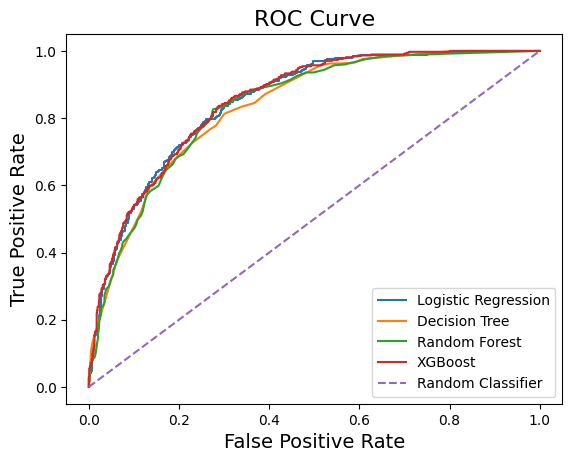

In [ ]:
for model_name in predictions:
    fpr,tpr,thresholds = roc_curve(
        y_test,probabilities[model_name]
    )
    plt.plot(fpr,tpr,label = model_name)
plt.plot([0,1],[0,1],"--",label = "Random Classifier")
plt.title("ROC Curve",fontsize = 16)
plt.xlabel("False Positive Rate",fontsize = 14)
plt.ylabel("True Positive Rate",fontsize = 14)
plt.legend()
plt.show()

## False Negative Analysis

False negatives represent customers who actually churned but were predicted as non-churners.

In a customer retention scenario, these cases are important because the business may fail to identify customers who require retention interventions.

Therefore, recall and the number of false negatives are considered when selecting the final model.

In [ ]:
False_Negative_Results = []
for model_name in predictions:
    cm  = confusion_matrix(
        y_test,predictions[model_name]
    )
    tn,fp,fn,tp = cm.ravel()
    False_Negative_Results.append([model_name,fn])
print(False_Negative_Results)



[['Logistic Regression', np.int64(169)], ['Decision Tree', np.int64(151)], ['Random Forest', np.int64(193)], ['XGBoost', np.int64(172)]]


In [ ]:
fn_df = pd.DataFrame(
    False_Negative_Results,
    columns = ["Model","False Negatives"]
).sort_values(
    by = "False Negatives",
    ascending = True
)
print(fn_df)

                 Model  False Negatives
1        Decision Tree              151
0  Logistic Regression              169
3              XGBoost              172
2        Random Forest              193


## Best Model Selection

The four classification models were compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and False Negatives.

XGBoost achieved the highest Accuracy (80.34%), Precision (65.80%), and ROC-AUC (85.18%).

However, Decision Tree achieved the highest Recall (59.63%) and F1-Score (60.52%) and produced the lowest number of False Negatives (151).

Since the primary business objective of this project is to identify customers who are likely to churn, correctly identifying actual churners is particularly important.

Therefore, Decision Tree is selected as the final model because it provides the best balance between identifying churners and overall classification performance, while producing the fewest missed churn cases.

In [ ]:
print(results_df)
print(fn_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.800568   0.646688  0.548128  0.593343  0.849363
1        Decision Tree  0.793471   0.614325  0.596257  0.605156  0.834506
2        Random Forest  0.785664   0.624138  0.483957  0.545181  0.836783
3              XGBoost  0.803407   0.657980  0.540107  0.593245  0.851789
                 Model  False Negatives
2        Random Forest              193
3              XGBoost              172
0  Logistic Regression              169
1        Decision Tree              151


## Define Best Model:

In [ ]:
best_model_name ="Decision Tree"

In [ ]:
best_model = models[best_model_name]
print(best_model)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges', 'CLTV',
                                                   'Total Aditional Services',
                                                   'Total Streaming Services',
                                                   'Total Security Services',
                                                   'Has Multiple Services']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                  

## Save Final Model

The selected Decision Tree pipeline is saved as the final churn prediction model.

The pipeline contains both the preprocessing steps and the trained classification model. Therefore, the same transformations used during training will automatically be applied when the model is used for future predictions.

The saved model will be used in the Explainable AI and deployment phases.

In [ ]:
joblib.dump(
    best_model,
    "final_churn_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


## Save Evaluation Results:

In [ ]:
results_df.to_csv(
    "model_evaluation_results.csv",
    index=False
)
print("Evaluation results saved sucessfully")

Evaluation results saved sucessfully


## Key Evaluation Findings

The four machine learning models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrices, classification reports, and false-negative analysis.

- XGBoost achieved the highest Accuracy (80.34%), Precision (65.80%), and ROC-AUC (85.18%).
- Decision Tree achieved the highest Recall (59.63%) and F1-Score (60.52%).
- Decision Tree produced the lowest number of False Negatives (151), meaning it missed fewer actual churners than the other models.
- Logistic Regression achieved an Accuracy of 80.06% and ROC-AUC of 84.94%, providing a strong baseline performance.
- Random Forest produced the lowest overall performance, with an Accuracy of 78.57%, Recall of 48.40%, and F1-Score of 54.52%.
- Because identifying actual churners is a key business objective, Recall, F1-Score, and False Negatives were given particular importance during model selection.
- Based on these considerations, Decision Tree was selected as the final model for the Explainable AI phase.

## Conclusion

In this notebook, four machine learning classification models were evaluated for customer churn prediction.

The models were compared using multiple performance metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Confusion matrices, classification reports, ROC curves, and false-negative analysis were also used to obtain a more comprehensive understanding of model performance.

Although XGBoost achieved the highest Accuracy, Precision, and ROC-AUC, Decision Tree achieved the highest Recall and F1-Score and produced the fewest False Negatives.

Since identifying customers who are likely to churn is the primary business objective, Decision Tree was selected as the final model.

The selected model has been saved and will be carried forward to the next phase of the project: Explainable AI using SHAP.